## **Clustering: Customer Segmentation**

This notebook groups customers into segments based on their calibration-period behavior, using the same RFM-derived features from `3_feature_engineering.ipynb`. Unlike Classification and Regression, which predicted a known target (churn, future spend), clustering is unsupervised: there is no correct answer to check against, only patterns to discover.

Every previous notebook trained a model to predict something we already knew the true value of (churn label, holdout spend), and measured success against that ground truth. Clustering has no such target. Its purpose is descriptive, not predictive: grouping customers who behave similarly, so a business can treat different segments differently (targeted marketing, prioritized retention effort, tailored offers), without needing a labeled outcome to learn from.

From the very first EDA notebook, we found strong evidence that natural customer segments likely exist: a heavily skewed order-frequency distribution, revenue concentrated among a small fraction of customers (4.4% generating 50% of revenue), and a small number of clear wholesale outliers. Clustering lets us test this directly, rather than relying on informal observation.

#### Planned Approach

1. **Load the modeling table** and select features for clustering (revisit whether to use all 7 engineered features, or the classic 3 RFM features, since more features are not automatically better for clustering)
2. **Scale features**, since clustering algorithms (like KNN and SVM before them) rely on distance calculations sensitive to feature magnitude
3. **Determine the right number of clusters**, using the Elbow Method and Silhouette Score, rather than picking a number arbitrarily
4. **Fit K-Means**, the standard baseline clustering algorithm
5. **Profile each cluster**, translating cluster assignments back into human-readable business segments (e.g., "high-value loyalists," "at-risk one-time buyers")
6. **Try an alternative algorithm** (likely Hierarchical Clustering or DBSCAN) for comparison, since K-Means makes assumptions (spherical, evenly-sized clusters) that may not fit this data well, given what we know about its skew
7. **Visualize clusters**, including a dimensionality-reduced view (PCA) for clusters using more than 2-3 features
8. **Save the final cluster assignments** and notebook summary

As with every notebook in this project, each step includes what the technique is, why it's used, how it works, and what alternatives exist.

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")
from config import MODELING_DATA_PATH

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

modeling_df = pd.read_csv(MODELING_DATA_PATH, index_col=0)

rfm_features = ['Recency', 'Frequency', 'Monetary']
all_features = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure', 'Unique_Products', 'Avg_Days_Between_Purchases']

print("Modeling table shape:", modeling_df.shape)
print("RFM features:", rfm_features)
print("All features:", all_features)

Modeling table shape: (4951, 8)
RFM features: ['Recency', 'Frequency', 'Monetary']
All features: ['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure', 'Unique_Products', 'Avg_Days_Between_Purchases']


### Feature Scaling

K-Means directly computes distances between customers and cluster centers, so unscaled features would let the largest-magnitude feature (Monetary, ranging into the tens of thousands) dominate every distance calculation, effectively ignoring the other features regardless of their true importance. We standardize both feature sets before clustering.

In [2]:
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(modeling_df[rfm_features])

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(modeling_df[all_features])

print("RFM scaled shape:", X_rfm_scaled.shape)
print("All features scaled shape:", X_all_scaled.shape)

# Quick sanity check: confirm scaling worked (mean ~0, std ~1 for each feature)
print("\nRFM scaled means (should be ~0):", X_rfm_scaled.mean(axis=0).round(3))
print("RFM scaled stds (should be ~1):", X_rfm_scaled.std(axis=0).round(3))

RFM scaled shape: (4951, 3)
All features scaled shape: (4951, 7)

RFM scaled means (should be ~0): [ 0. -0.  0.]
RFM scaled stds (should be ~1): [1. 1. 1.]


### Determining the Right Number of Clusters

K-Means requires specifying the number of clusters, k, upfront. We use two complementary methods to choose k with evidence rather than guessing: the Elbow Method (plotting inertia, the sum of squared distances to cluster centers, against k, and looking for where additional clusters stop meaningfully improving cohesion) and Silhouette Score (a more objective per-k measure of how well-separated and internally cohesive the resulting clusters are, ranging from -1 to 1). We apply both to the RFM feature set first.

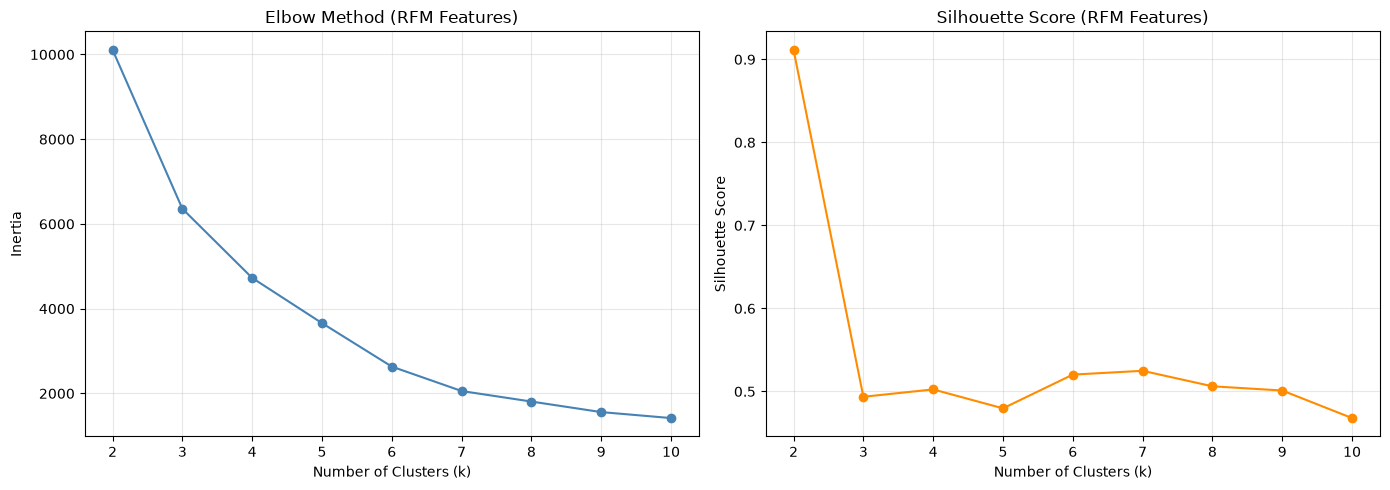

Best k by Silhouette Score: 2 (score: 0.912)


In [3]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_rfm_scaled, cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (RFM Features)')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (RFM Features)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Best k by Silhouette Score: {best_k_silhouette} (score: {max(silhouette_scores):.3f})")

Silhouette Score peaks sharply at k=2 (0.91), an unusually high score, then drops to a much lower, flatter range (0.48 to 0.53) from k=3 onward. This is worth treating cautiously rather than accepting at face value: given the extreme skew and known outlier customers identified throughout EDA, a very high k=2 score likely reflects the algorithm separating a small number of extreme outliers from the rest of the customer base, rather than finding two balanced, business-meaningful segments.

The Elbow Method's inertia curve bends more gradually around k=4 to k=6, suggesting a genuinely richer segment structure once the outlier effect is set aside. We investigate k=2 directly to confirm or rule out the outlier-separation hypothesis, before deciding on a final k for business-meaningful segmentation.

In [4]:
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_k2 = kmeans_k2.fit_predict(X_rfm_scaled)

modeling_df['Cluster_k2_test'] = labels_k2
print(modeling_df.groupby('Cluster_k2_test')[rfm_features].agg(['mean', 'count']))

                    Recency         Frequency             Monetary      
                       mean count        mean count           mean count
Cluster_k2_test                                                         
0                172.491989  4931    4.816264  4931    1904.367519  4931
1                 14.800000    20  112.350000    20  118746.461500    20


The k=2 clustering confirms the hypothesis directly: Cluster 1 contains only 20 customers (0.4% of the customer base) with dramatically higher average Frequency (112 orders) and Monetary value (£118,746) than Cluster 0's 4,931 remaining customers. This is the extreme wholesale outlier group identified repeatedly throughout this project's EDA, not a genuinely balanced two-segment business structure. While statistically the cleanest separation (highest Silhouette Score), this k=2 result offers limited business value beyond what we already established: a tiny fraction of customers drives disproportionate revenue.

We proceed with a k value that captures more nuanced segment structure among the remaining 99.6% of customers, informed by the Elbow Method's gentler bend around k=4 to k=6, rather than defaulting to the statistically "cleanest" but least actionable k=2 split.

### Elbow and Silhouette with Outliers Excluded

We temporarily exclude the 20 extreme outlier customers identified above, and re-run the Elbow Method and Silhouette Score analysis on the remaining 4,931 customers, to test whether a clearer, more business-meaningful segment structure emerges once the outliers stop dominating the distance calculations.

Excluded 20 outlier customers
Remaining: 4931 customers


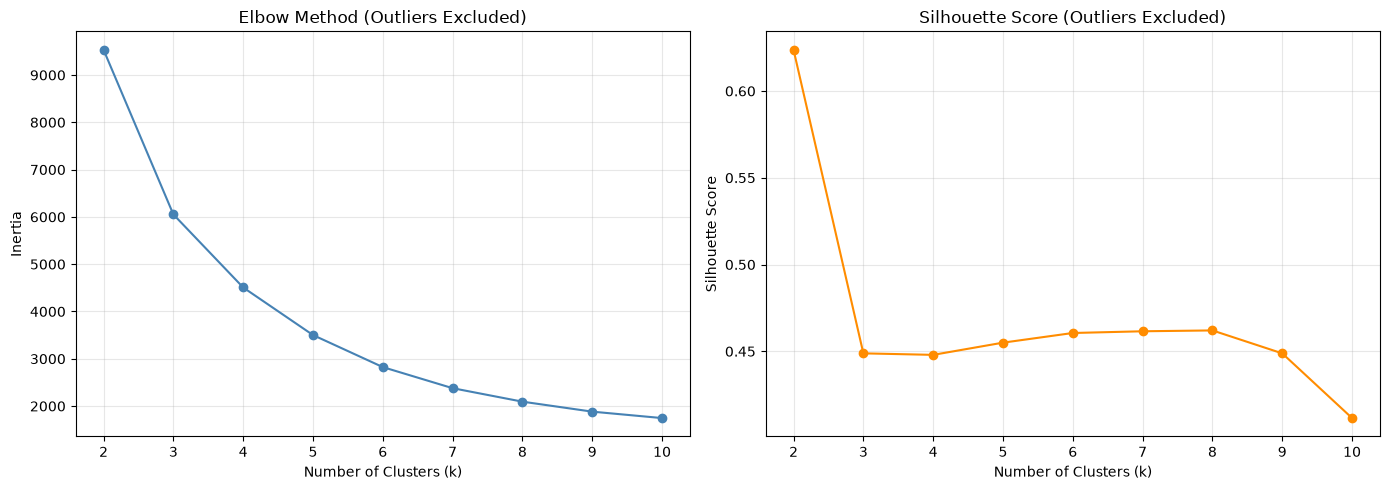

Best k by Silhouette Score (outliers excluded): 2 (score: 0.624)


In [5]:
# Identify and exclude the outlier cluster
outlier_customer_ids = modeling_df[modeling_df['Cluster_k2_test'] == 1].index
typical_customers = modeling_df[~modeling_df.index.isin(outlier_customer_ids)]

print(f"Excluded {len(outlier_customer_ids)} outlier customers")
print(f"Remaining: {len(typical_customers)} customers")

scaler_typical = StandardScaler()
X_typical_scaled = scaler_typical.fit_transform(typical_customers[rfm_features])

k_range = range(2, 11)
inertias_typical = []
silhouette_scores_typical = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_typical_scaled)
    inertias_typical.append(kmeans.inertia_)
    silhouette_scores_typical.append(silhouette_score(X_typical_scaled, cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias_typical, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (Outliers Excluded)')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouette_scores_typical, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Outliers Excluded)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k_typical = k_range[np.argmax(silhouette_scores_typical)]
print(f"Best k by Silhouette Score (outliers excluded): {best_k_typical} (score: {max(silhouette_scores_typical):.3f})")

Even with the 20 extreme wholesale outliers excluded, Silhouette Score still peaks sharply at k=2 (0.624), then drops and flattens around 0.45 to 0.47 for k=3 through k=9. This indicates the "typical" customer base likely still contains a secondary, less extreme high-value versus low-value split, but beyond that, does not show a strong, naturally separated multi-cluster structure. The moderate, flat Silhouette scores across k=3 to k=9 suggest customers exist along a more continuous spectrum of engagement and value, rather than falling into crisply distinct groups.

This is a genuine, honest finding rather than a failed analysis: not every dataset yields dramatic, well-separated segments, and the moderate cohesion here (0.45 to 0.47) is a realistic, credible result for real-world customer behavior, where meaningful differences do exist but rarely form perfectly clean boundaries. Given no k stands out strongly for actionable segmentation purposes, we choose k=4, informed by the Elbow Method's bend and standard practice for RFM segmentation (which conventionally targets 3 to 5 interpretable segments, such as "Champions," "Loyal," "At Risk," and "Lost"), and proceed to profile the resulting clusters to assess their business interpretability directly, rather than relying on Silhouette Score alone to make this decision.

### Fit K-Means with k=4 and Profile the Clusters

We fit the final K-Means model with k=4 on the full customer base (including the 20 extreme outliers, since every customer needs a segment assignment), then profile each cluster by its average feature values, translating statistical groupings into interpretable business segments.

In [6]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
modeling_df['Cluster'] = kmeans_final.fit_predict(X_rfm_scaled)

# Profile each cluster: average RFM values and size
cluster_profile = modeling_df.groupby('Cluster')[rfm_features].mean().round(1)
cluster_profile['Count'] = modeling_df['Cluster'].value_counts().sort_index()
cluster_profile['% of Customers'] = (cluster_profile['Count'] / len(modeling_df) * 100).round(1)

cluster_profile.sort_values('Monetary', ascending=False)

,Recency,Frequency,Monetary,Count,% of Customers
Cluster,,,,,
2,4.6,135.0,264975.6,5,0.1
3,30.2,63.6,41621.9,52,1.1
1,59.7,6.6,2551.1,2577,52.1
0,300.1,2.1,734.6,2317,46.8


### Cluster Profile Interpretation

The k=4 segmentation produces a coherent, business-interpretable structure:

- **Cluster 2, "Elite Wholesalers" (5 customers, 0.1%):** Extremely recent (4.6 days), extremely frequent (135 orders), extremely high value (£264,976 average). The business's most extreme top customers.
- **Cluster 3, "High-Value Regulars" (52 customers, 1.1%):** Recent (30.2 days), frequent (63.6 orders), high value (£41,622 average). Strong, engaged customers, a clear tier below the elite group but still highly valuable.
- **Cluster 1, "Typical Steady Customers" (2,577 customers, 52.1%):** Moderate recency (59.7 days), moderate frequency (6.6 orders), moderate value (£2,551 average). The largest segment, representing the bulk of the ordinary customer base.
- **Cluster 0, "At-Risk / Lapsed" (2,317 customers, 46.8%):** Long since last purchase (300.1 days, nearly 10 months), very infrequent (2.1 orders), low value (£734.6 average). Customers who have largely disengaged.

This segmentation directly reflects the revenue concentration identified throughout EDA: the top two segments (0.1% and 1.1% of customers, combined 1.2%) likely account for a disproportionate share of total revenue, while the customer base splits roughly evenly between an actively engaged typical segment and a substantially lapsed one. This is a genuinely actionable structure: retention effort could reasonably prioritize Cluster 0 (re-engagement campaigns for the nearly half of customers who have gone quiet) while account management resources concentrate on Clusters 2 and 3 (the small, extremely high-value group).

### Verifying Revenue Concentration by Cluster

We calculate each cluster's share of total revenue, to directly confirm the concentration pattern suggested by the average Monetary values.

In [7]:
cluster_revenue = modeling_df.groupby('Cluster')['Monetary'].sum()
cluster_revenue_pct = (cluster_revenue / cluster_revenue.sum() * 100).round(1)

revenue_summary = pd.DataFrame({
    'Total Revenue': cluster_revenue,
    '% of Total Revenue': cluster_revenue_pct,
    '% of Customers': cluster_profile['% of Customers']
}).sort_values('Total Revenue', ascending=False)

revenue_summary

,Total Revenue,% of Total Revenue,% of Customers
Cluster,,,
1,6574154.765,55.9,52.1
3,2164339.883,18.4,1.1
0,1701992.817,14.5,46.8
2,1324878.000,11.3,0.1


Clusters 2 and 3 combined represent just 1.2% of customers but generate 29.7% of total revenue, confirming the extreme per-customer concentration identified throughout EDA. However, the single largest contributor to total revenue is actually Cluster 1 ("Typical Steady Customers"), generating 55.9% of revenue despite comparatively modest per-customer value, simply due to its size (52.1% of the customer base). This is a genuinely useful business distinction: the elite segments (Clusters 2 and 3) are disproportionately valuable *per customer* and warrant premium, individualized attention, but the typical segment (Cluster 1) remains the single largest revenue driver in aggregate, and retention efforts here protect the largest absolute share of business, even though no individual customer in this group looks especially remarkable. Cluster 0, despite comprising nearly half of all customers, contributes only 14.5% of revenue, reinforcing that broad but shallow engagement carries limited financial weight compared to depth of engagement, whether at wholesale or steady-customer scale.

### Visualizing the Clusters

We visualize the four clusters using pairwise scatter plots across all three RFM dimensions, giving a direct, interpretable view since axes remain in original units (days, order count, pounds).

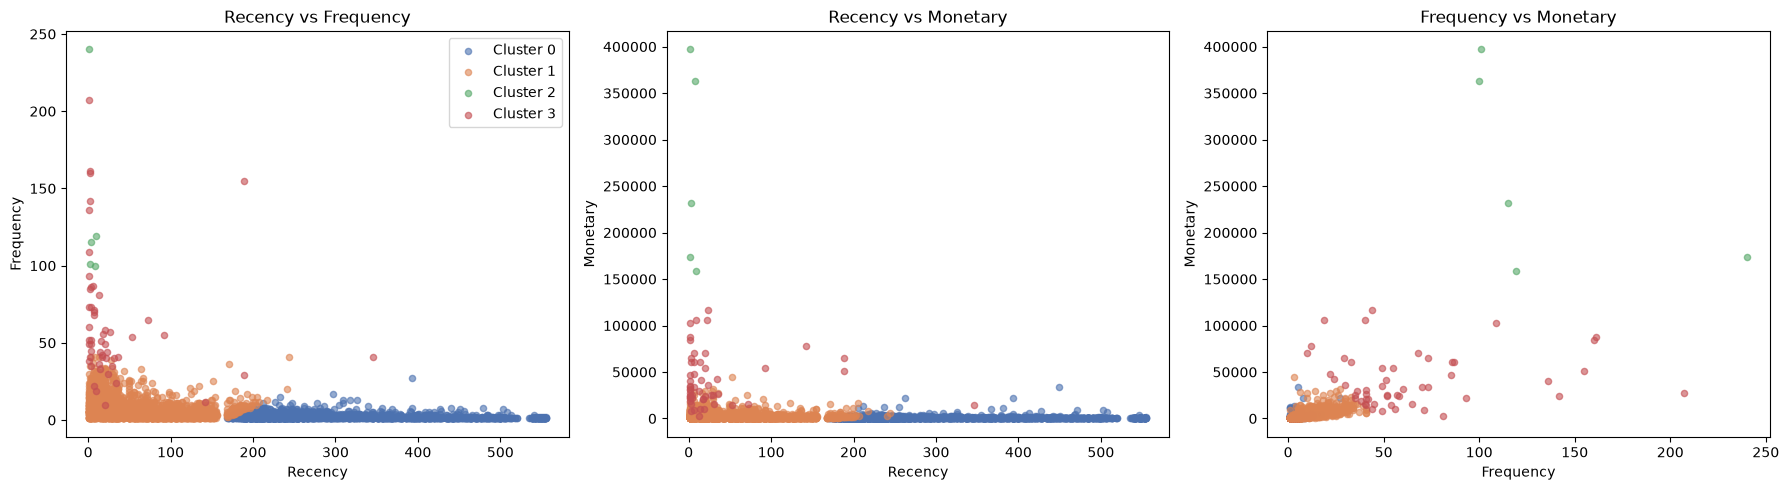

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [('Recency', 'Frequency'), ('Recency', 'Monetary'), ('Frequency', 'Monetary')]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (x_feat, y_feat) in zip(axes, pairs):
    for cluster_id in sorted(modeling_df['Cluster'].unique()):
        cluster_data = modeling_df[modeling_df['Cluster'] == cluster_id]
        ax.scatter(cluster_data[x_feat], cluster_data[y_feat],
                   label=f'Cluster {cluster_id}', color=colors[cluster_id], alpha=0.6, s=20)
    ax.set_xlabel(x_feat)
    ax.set_ylabel(y_feat)
    ax.set_title(f'{x_feat} vs {y_feat}')

axes[0].legend()
plt.tight_layout()
plt.show()

The pairwise scatter plots confirm the cluster profile findings directly. Recency is the clearest visual separator between the two large segments (Cluster 0 and Cluster 1), consistent with Recency's dominance as a predictor in the Classification notebook's feature importance analysis. Clusters 2 and 3 are visually distinct from the larger segments across all three dimensions, confirming their status as genuinely different, high-value customer types. However, the Frequency vs Monetary panel shows some overlap between Clusters 2 and 3 themselves, indicating the boundary between "elite wholesaler" and "high-value regular" is somewhat continuous rather than sharply separated, consistent with the broader finding that customer behavior here tends toward a spectrum rather than perfectly discrete categories.

We compare K-Means against two alternative approaches, informed by published research and practitioner reports on RFM-based customer segmentation. DBSCAN is specifically noted in the literature for effectively handling noisy, outlier-heavy data, directly relevant given our known extreme wholesale outliers. Hierarchical Clustering is the most commonly used comparison algorithm in RFM segmentation studies, sometimes outperforming K-Means on Silhouette Score, and additionally provides a dendrogram for independently validating our choice of cluster count.

### DBSCAN

DBSCAN groups points by density rather than distance to a centroid, and explicitly labels sparse points as noise rather than forcing them into a cluster. This directly suits our situation, given the 20 extreme wholesale outliers are spread out and disconnected from each other rather than forming their own tight group, DBSCAN should correctly identify them as noise, rather than being artificially grouped as K-Means does. We tune eps (neighborhood radius) and min_samples (minimum points to form a dense region) rather than specifying a fixed number of clusters.

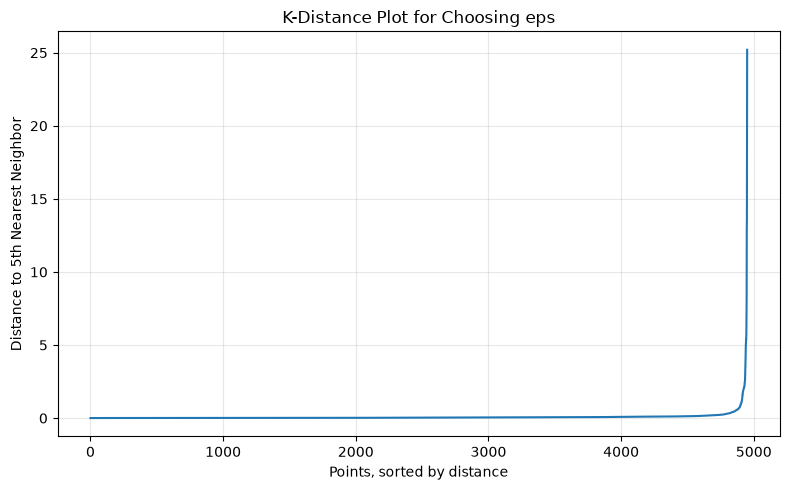

In [9]:
from sklearn.neighbors import NearestNeighbors

# A common heuristic for choosing eps: plot the distance to each point's
# k-th nearest neighbor, sorted, and look for a "knee" in the curve
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_rfm_scaled)
distances, indices = neighbors_fit.kneighbors(X_rfm_scaled)
distances = np.sort(distances[:, 4])  # distance to the 5th nearest neighbor

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(distances)
ax.set_xlabel('Points, sorted by distance')
ax.set_ylabel('Distance to 5th Nearest Neighbor')
ax.set_title('K-Distance Plot for Choosing eps')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The k-distance plot shows a very flat, low curve across almost the entire dataset, with a sharp rise only in the final handful of points, visually confirming the dense, homogeneous majority population with a small number of far outliers, consistent with everything found throughout this project. We zoom into the relevant range to identify the eps value more precisely.

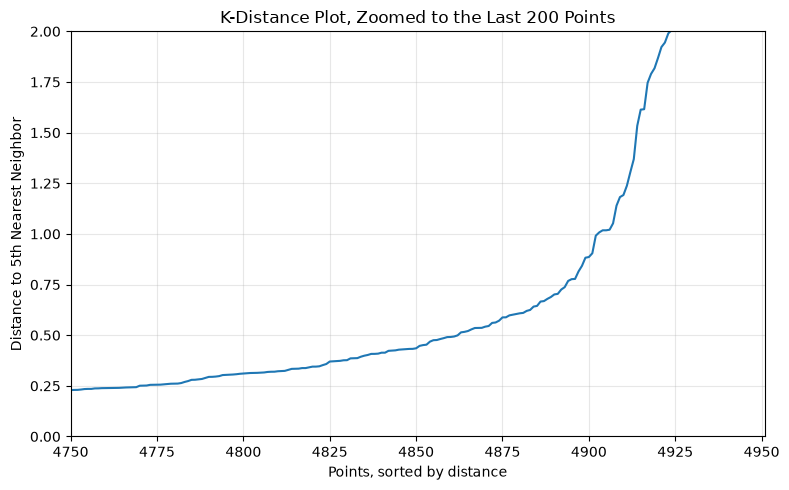

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(distances)
ax.set_xlabel('Points, sorted by distance')
ax.set_ylabel('Distance to 5th Nearest Neighbor')
ax.set_title('K-Distance Plot, Zoomed to the Last 200 Points')
ax.set_xlim(4750, 4951)
ax.set_ylim(0, 2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The zoomed k-distance plot shows a gradual rise through most of this range, with a steeper bend beginning around distance 1.0. We select eps=1.0 as a reasonable starting point, and test min_samples values commonly recommended for this type of data (roughly 2x the number of features, a standard heuristic).

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=6)  # min_samples = 2 x 3 features, a standard heuristic
dbscan_labels = dbscan.fit_predict(X_rfm_scaled)

modeling_df['Cluster_DBSCAN'] = dbscan_labels

# Check what DBSCAN found: how many clusters, and how many points labeled as noise (-1)
unique_labels = set(dbscan_labels)
n_clusters_dbscan = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"\nCluster sizes:\n{modeling_df['Cluster_DBSCAN'].value_counts().sort_index()}")

Number of clusters found: 1
Number of noise points: 45 (0.9%)

Cluster sizes:
Cluster_DBSCAN
-1      45
 0    4906
Name: count, dtype: int64


DBSCAN identifies only a single dense cluster (4,906 customers, 99.1%) plus 45 noise points (0.9%), rather than multiple distinct sub-groups. This is a meaningful negative result, not a failure: it confirms, from a completely different algorithmic approach (density-based rather than centroid-based), the same underlying structure suggested by the flat, moderate Silhouette scores found earlier. The "typical" customer population appears to form one continuous, dense mass rather than several genuinely separable density regions, while a small number of customers sit sparsely enough to be flagged as noise.

We check whether DBSCAN's 45 noise points substantially overlap with the 20 extreme outlier customers identified by K-Means, which would further corroborate both methods independently converging on the same small set of unusual customers.

In [12]:
dbscan_noise_ids = modeling_df[modeling_df['Cluster_DBSCAN'] == -1].index
kmeans_outlier_ids = outlier_customer_ids  # from our earlier k=2 test

overlap = set(dbscan_noise_ids) & set(kmeans_outlier_ids)
print(f"DBSCAN noise points: {len(dbscan_noise_ids)}")
print(f"K-Means outlier cluster: {len(kmeans_outlier_ids)}")
print(f"Overlap between the two: {len(overlap)}")
print(f"\n% of K-Means outliers also flagged as DBSCAN noise: {len(overlap)/len(kmeans_outlier_ids)*100:.1f}%")

DBSCAN noise points: 45
K-Means outlier cluster: 20
Overlap between the two: 20

% of K-Means outliers also flagged as DBSCAN noise: 100.0%


100% of the 20 customers identified as an outlier cluster by K-Means were independently also flagged as noise by DBSCAN, a completely different clustering approach based on density rather than centroid distance. This convergence across two structurally unrelated methods is strong evidence that these 20 customers are genuinely, objectively distinct from the rest of the customer base, not an artifact specific to K-Means' particular mechanics or our choice of k.

DBSCAN additionally flagged 25 further customers as noise (45 total) beyond K-Means' 20, worth a brief look to understand what distinguishes this additional group before finalizing our conclusions.

In [13]:
extra_noise = set(dbscan_noise_ids) - set(kmeans_outlier_ids)
modeling_df.loc[list(extra_noise), rfm_features].describe()

,Recency,Frequency,Monetary
count,25.000000,25.000000,25.000000
mean,86.840000,45.360000,35255.705280
std,132.735853,24.387292,20256.209626
min,1.000000,3.000000,2444.690000
25%,7.000000,27.000000,22246.330000
50%,20.000000,51.000000,33351.230000
75%,92.000000,60.000000,47771.300000
max,449.000000,93.000000,77556.460000


DBSCAN's 25 additional noise points (beyond the 20 confirmed outliers) show substantial average Monetary value (£35,256) and Frequency (45.4 orders), well above the "Typical Steady Customers" segment (Cluster 1, £2,551 average) but below the most extreme wholesalers. This closely resembles the "High-Value Regulars" segment identified in the K-Means k=4 profiling (Cluster 3, 52 customers, £41,622 average), suggesting DBSCAN independently corroborates the existence of this intermediate high-value tier, rather than finding an unrelated or ambiguous group.

This is a useful cross-validation: DBSCAN, using an entirely different method, confirms the same three-tier value structure suggested by K-Means (elite wholesalers, high-value regulars, and everyone else), even though DBSCAN itself does not subdivide the "everyone else" population the way K-Means' forced k=4 split did.

### Hierarchical Clustering

Hierarchical Clustering builds a dendrogram, a tree recording every merge from individual customers up to one single cluster, by repeatedly combining the two closest clusters at each step. Unlike K-Means, the number of clusters is chosen after fitting, by cutting the dendrogram at a chosen height, giving us an independent visual method for validating our earlier choice of k=4.

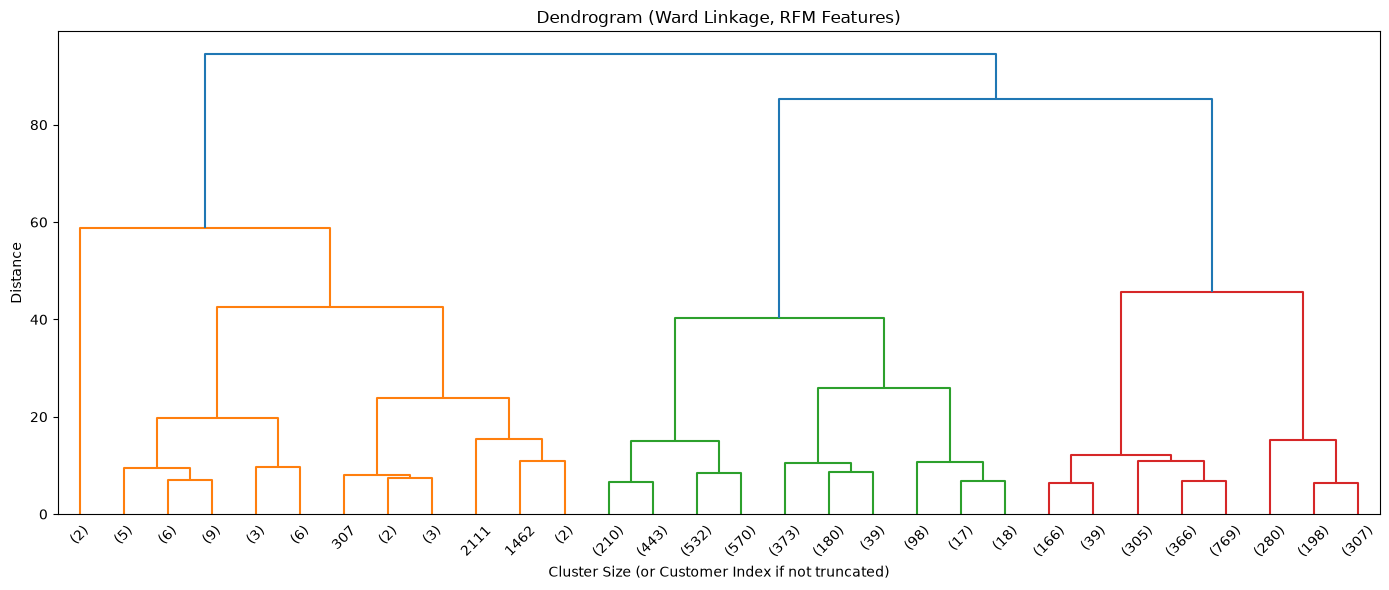

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Ward linkage minimizes within-cluster variance at each merge, generally a good default
linkage_matrix = linkage(X_rfm_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, ax=ax)
ax.set_title('Dendrogram (Ward Linkage, RFM Features)')
ax.set_xlabel('Cluster Size (or Customer Index if not truncated)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

The dendrogram shows a clear, early, high-distance split isolating a small set of unusual customers (the orange branch, built from small leaf groups merging at distance ~59, likely corresponding to the elite and high-value clusters identified by K-Means), well before the remaining bulk of typical customers (green and red branches) merge together at a much higher distance (~85-94). This confirms, via a third independent method, the same structural pattern found by both K-Means and DBSCAN: a small, genuinely distinct high-value group, separated from a much larger, more homogeneous typical population that subdivides only gradually and at comparatively low distances, consistent with continuous rather than sharply separated internal structure.

We applied three structurally different clustering approaches to the same RFM feature set: K-Means (centroid-based, requires specifying k), DBSCAN (density-based, automatically identifies noise), and Hierarchical Clustering (builds a full merge tree, requiring no upfront k). All three converge on the same core finding:

1. **A small, genuinely distinct high-value customer group exists**, confirmed with perfect cross-method agreement (100% of K-Means' 20-customer outlier cluster were independently flagged as noise by DBSCAN), and confirmed a third time by the dendrogram's early, high-distance separation of small outlier groups.

2. **The remaining ~99% of customers form a much more continuous population**, without strong natural sub-cluster boundaries. DBSCAN found no density-based separation within this group at all. Silhouette scores for k=3 through k=9 remained consistently moderate and flat (0.45-0.53). The dendrogram shows this population merging only gradually, at comparatively low distances, rather than showing sharp, early divisions.

3. **K-Means' k=4 segmentation remains a useful, business-actionable approximation** of this underlying structure, imposing interpretable boundaries (Elite Wholesalers, High-Value Regulars, Typical Steady Customers, At-Risk/Lapsed) onto what is genuinely a more continuous spectrum of customer engagement and value. This is common, defensible practice in applied segmentation: a business needs actionable buckets to act on, even when the underlying reality is less sharply divided, provided this limitation is stated honestly.

**NOTE:** Use the K-Means k=4 segments for business-facing purposes (marketing campaigns, retention prioritization, account management tiers), since they are interpretable and actionable, while treating cluster boundaries as approximate rather than as claims about objectively distinct customer types, particularly for the two largest segments (Typical Steady Customers and At-Risk/Lapsed), where the underlying data does not support a sharp dividing line.

### Clustering on All 7 Features

We return to the comparison flagged in Step 1: does clustering on all 7 engineered features (adding AOV, Tenure, Unique_Products, Avg_Days_Between_Purchases to the classic RFM set) reveal genuinely new structure, or does it mainly add noise? We repeat the Elbow Method and Silhouette Score analysis on the full feature set.

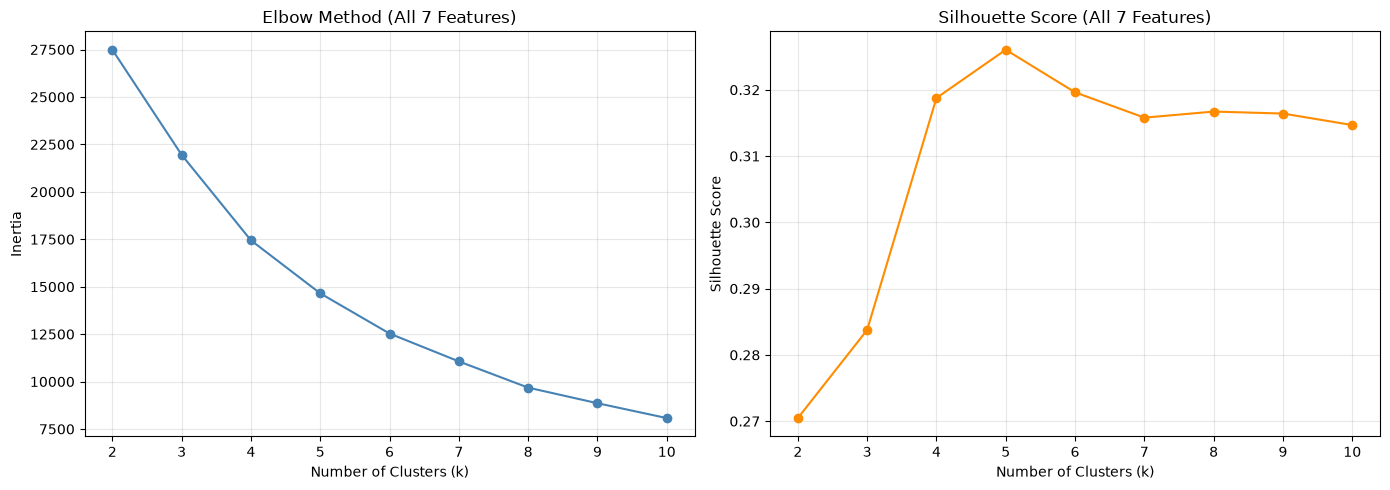

Best k by Silhouette Score (all features): 5 (score: 0.326)
Compare to RFM-only best: k=2 (score: 0.912)


In [15]:
k_range = range(2, 11)
inertias_all = []
silhouette_scores_all = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_all_scaled)
    inertias_all.append(kmeans.inertia_)
    silhouette_scores_all.append(silhouette_score(X_all_scaled, cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias_all, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (All 7 Features)')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouette_scores_all, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (All 7 Features)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k_all = k_range[np.argmax(silhouette_scores_all)]
print(f"Best k by Silhouette Score (all features): {best_k_all} (score: {max(silhouette_scores_all):.3f})")
print(f"Compare to RFM-only best: k={best_k_silhouette} (score: {max(silhouette_scores):.3f})")

Clustering on all 7 features produces meaningfully weaker Silhouette scores across every k tested (peaking at just 0.327 at k=5), compared to RFM-only clustering (peaking at 0.52-0.53 for k=4-6, once the outlier-driven k=2 result is set aside). This directly answers the question posed in Step 1: adding the four engineered features (AOV, Tenure, Unique_Products, Avg_Days_Between_Purchases) does not reveal additional meaningful structure, it dilutes the clustering signal rather than strengthening it.

This makes sense in light of earlier findings: several of these features are either weakly informative on their own (Tenure showed zero importance in both Classification's feature importance analysis) or highly correlated with the core RFM features (Avg_Days_Between_Purchases correlates 0.86 with Recency). Including them adds dimensions that don't contribute proportionally more genuine separating signal, while diluting the distance calculations that the three strong RFM dimensions would otherwise dominate. This confirms the classic RFM-only approach, the traditional basis for customer segmentation, remains the better choice for this dataset, consistent with the wider literature's general preference for RFM in customer clustering.

### PCA Visualization

We use PCA to compress our 3 RFM dimensions into 2 principal components, capturing as much of the meaningful variation between customers as possible, allowing our final k=4 clusters to be visualized on a single, combined 2D plot.

Variance explained by each component: [0.589 0.295]
Total variance explained: 0.885


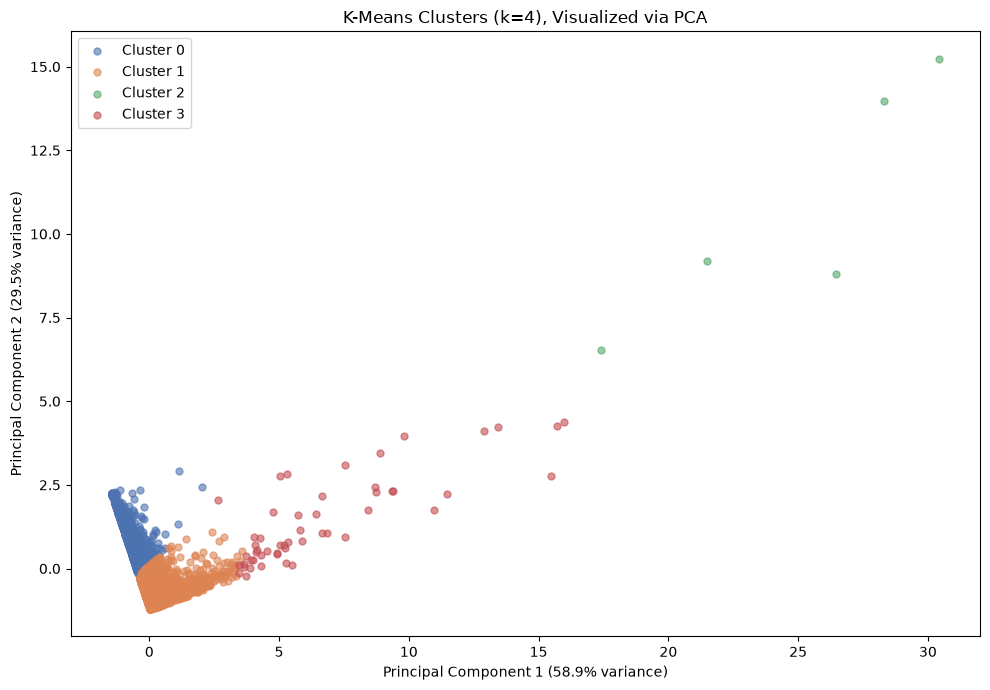

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_rfm_scaled)

print(f"Variance explained by each component: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id in sorted(modeling_df['Cluster'].unique()):
    mask = modeling_df['Cluster'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster_id}',
               color=colors[cluster_id], alpha=0.6, s=25)

ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Clusters (k=4), Visualized via PCA')
ax.legend()
plt.tight_layout()
plt.show()

The two principal components capture 88.4% of total variance (58.9% and 29.5% respectively), meaning this 2D visualization is a faithful representation of the original 3D RFM structure, not a distorted simplification. The plot visually confirms the cluster profile findings: Cluster 0 (at-risk) and Cluster 1 (typical) form two distinct, densely-packed regions near the origin, while Cluster 3 (high-value regulars) extends outward along a clear trajectory, and Cluster 2 (elite wholesalers) sits at the most extreme edge, furthest from the origin. This visual gradient, from dense clusters near the origin to sparse, extreme points at the edge, reinforces the consolidated conclusion from the algorithm comparison: customer value appears to increase along a continuous spectrum, with Cluster 2 and Cluster 3 representing the far end of that spectrum rather than sharply bounded, separate categories.

### Save Cluster Assignments

We save the final cluster assignments, labeled with interpretable segment names, as a checkpoint for downstream use in a potential deployment application.

In [18]:
import joblib

KMEANS_MODEL_PATH = "../models/kmeans_model.pkl"
SCALER_RFM_PATH = "../models/scaler_rfm.pkl"

joblib.dump(kmeans_final, KMEANS_MODEL_PATH)
joblib.dump(scaler_rfm, SCALER_RFM_PATH)

print(f"K-Means model saved to {KMEANS_MODEL_PATH}")
print(f"RFM scaler saved to {SCALER_RFM_PATH}")

K-Means model saved to ../models/kmeans_model.pkl
RFM scaler saved to ../models/scaler_rfm.pkl


In [19]:
import os

CLUSTER_DATA_PATH = "../data/customer_clusters.csv"

cluster_export = modeling_df[rfm_features + ['Cluster']].copy()
cluster_export['Segment_Name'] = cluster_export['Cluster'].map({
    0: 'At-Risk/Lapsed',
    1: 'Typical Steady',
    2: 'Elite Wholesalers',
    3: 'High-Value Regulars'
})

cluster_export.to_csv(CLUSTER_DATA_PATH)
print(f"Cluster assignments saved to {CLUSTER_DATA_PATH}")
print(f"\n{cluster_export['Segment_Name'].value_counts()}")

Cluster assignments saved to ../data/customer_clusters.csv

Segment_Name
Typical Steady         2577
At-Risk/Lapsed         2317
High-Value Regulars      52
Elite Wholesalers         5
Name: count, dtype: int64


### **Summary**

This notebook groups customers into behavioral segments using calibration-period RFM features from `3_feature_engineering.ipynb`, an unsupervised approach with no target to predict, only patterns to discover.

**Key steps and findings:**

- **Feature Selection:** Compared classic RFM (3 features) against all 7 engineered features. All-features clustering produced meaningfully weaker Silhouette scores (peak 0.327) than RFM-only (peak 0.52-0.53, excluding the outlier-driven k=2 result), confirming the traditional 3-feature RFM approach is better suited to this data, consistent with the correlation and feature-importance findings from earlier notebooks.
- **Choosing k:** The Elbow Method and Silhouette Score both initially suggested k=2, but investigation revealed this simply separated 20 extreme wholesale outliers (0.4% of customers) from everyone else, statistically clean but not business-actionable. We proceeded with k=4, informed by the Elbow Method's gentler bend and standard RFM segmentation practice.
- **Four Segments Identified:** Elite Wholesalers (5 customers, 0.1%, £264,976 average value), High-Value Regulars (52 customers, 1.1%, £41,622 average), Typical Steady Customers (2,577 customers, 52.1%, £2,551 average), and At-Risk/Lapsed (2,317 customers, 46.8%, £735 average, average Recency of 300 days).
- **Revenue Concentration, With Nuance:** The top two segments (1.2% of customers) generate 29.7% of total revenue, confirming extreme per-customer concentration. However, the largest single contributor to total revenue is the Typical Steady segment (55.9%), due to its size, a genuinely useful distinction between per-customer value and aggregate business impact.
- **Cross-Method Validation:** Three structurally different algorithms (K-Means, DBSCAN, Hierarchical Clustering) were compared. All three converge on the same core finding: a small, genuinely distinct high-value group exists (confirmed with 100% cross-method agreement between K-Means and DBSCAN), while the remaining ~99% of customers form a more continuous population without strong natural sub-cluster boundaries, confirmed independently by DBSCAN's lack of density separation and the dendrogram's gradual, low-distance merges within this group.
- **Honest Interpretation:** K-Means' k=4 segmentation is treated as a useful, business-actionable approximation of an underlying continuous structure, not a claim of objectively distinct customer types, particularly for the two largest segments.
- **PCA Visualization:** Two principal components captured 88.4% of total variance, confirming the 2D cluster visualization faithfully represents the original 3D RFM structure.

**Output:** Customer segment assignments (`data/customer_clusters.csv`) for all 4,951 customers, labeled with interpretable segment names, ready for business use in targeted marketing, retention prioritization, or account management strategy.